In [44]:
from pathlib import Path
from loadPressureData import loadPressureData, matlab_datenum_to_datetime64
import numpy as np
from BulkWaveStats import wavenumber, sig_wave_height, Spp_to_Seta
from BulkWaveStats import  detide
from utide import solve, reconstruct
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.signal import spectrogram
import pandas as pd

# 22 October

In [17]:
### ----------- Load Data --------- ####

## ----- Sensor 1 ----- ##
bursts1 = loadPressureData(Path("data/MoA18411.mat"))
t1 = bursts1.time           # numpy datetime64[ns]
h1 = bursts1.depth_m       # hydrostatic depth in meters
p1 = bursts1.pressure_pa    # pressure converted to pascals
tide1, p1_detide, p1_raw = detide(p1, t1, LAT = 21.58055556) # seperate tidal signal

## ----- Sensor 6 ----- ##
bursts6 = loadPressureData(Path("data/MoA68411.mat"))
t6 = bursts6.time           # numpy datetime64[ns]
h6 = bursts6.depth_m       # hydrostatic depth in meters
p6 = bursts6.pressure_pa    # pressure converted to pascals
tide6, p6_detide, p6_raw = detide(p6, t6, LAT = 21.58055556) # seperate tidal signal

prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.


In [35]:
import numpy as np

def Spp_to_Seta_capped(
    Spp: np.ndarray,
    freqs: np.ndarray,
    t_spec: np.ndarray,
    t1: np.ndarray,
    h1: np.ndarray,
    *,
    kh_limit: float = 5.0,          # cap: keep bins where k*h <= kh_limit
    depth_interp: np.ndarray | None = None,
):
    Seta, time_centers, depth_at_centers = Spp_to_Seta(
        Spp, freqs, t_spec, t1, h1, depth_interp=depth_interp
    )

    omega = 2.0 * np.pi * np.asarray(freqs, dtype=float)

    # mask out bins where the transfer-function gain is too large
    valid = np.ones_like(Seta, dtype=bool)
    for col, depth_val in enumerate(depth_at_centers):
        k = wavenumber(omega, float(depth_val))
        valid[:, col] = (k * depth_val) <= kh_limit

    Seta_capped = Seta.copy()
    Seta_capped[~valid] = np.nan  # or 0.0 if you prefer to zero them out
    return Seta_capped, time_centers, depth_at_centers, valid


In [30]:
### ------- PSD Computation -------- ###
# INPUT VALUES
fs = 1.0 # sample rate in Hz
nperseg = 65536
noverlap = nperseg * 0.75 # 75% overlap

# S1 PSD
freqs1, t_spec1, Spp1 = spectrogram(
    p1_detide,
    fs=fs,
    window = 'hann',
    nperseg = nperseg,
    noverlap = noverlap, 
    detrend = 'constant',
    scaling = 'density',
    mode='psd', 
)
S1eta, t1_eta, eta1 = Spp_to_Seta(Spp1, freqs1, t_spec1, t1, h1)
S1eta_mean = np.nanmean(S1eta, axis=1)      # [freq]

# S6 PSD
freqs6, t_spec6, Spp6 = spectrogram(
    p6_detide,
    fs=fs,
    window = 'hann',
    nperseg = 32768,
    noverlap = 32768 * 0.75, 
    detrend = 'constant',
    scaling = 'density',
    mode='psd', 
)
S6eta, t6_eta, eta6 = Spp_to_Seta(Spp6, freqs6, t_spec6, t6, h6)
S6eta_mean = np.nanmean(S6eta, axis=1)      # [freq]

/var/folders/7q/04p1sn755vg5x39skt2hykjh0000gn/T/ipykernel_81508/2233342387.py:10: RuntimeWarning: Mean of empty slice
  autospec6 = np.nanmean(S6eta_cap, axis=1)


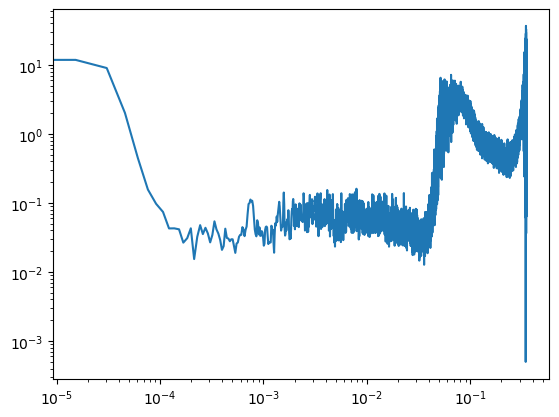

In [41]:
freqs6, t_spec6, Spp6 = spectrogram(
    p6_prime, fs=1.0, window="hann",
    nperseg=nperseg//2, noverlap=int(0.75 * 32768),
    detrend="linear", scaling="density", mode="psd"
)

S6eta_cap, t6_eta, depth6, mask6 = Spp_to_Seta_capped(
    Spp6, freqs6, t_spec6, t6, h6, kh_limit=5.0
)
autospec6 = np.nanmean(S6eta_cap, axis=1)

plt.loglog(freqs6, autospec6, label="Sensor 6 (kh≤5)")


Text(0.5, 1.0, 'Autospectra of detided surface elev spectra with nperseg=131072')

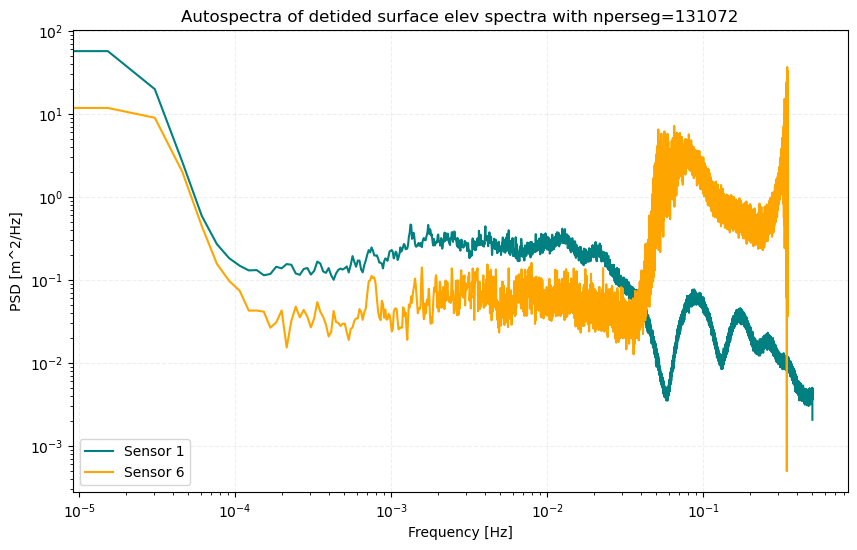

In [43]:
plt.figure(figsize=(10, 6))
plt.loglog(freqs1, S1eta_mean, color='teal', label='Sensor 1')
plt.loglog(freqs6, autospec6, color='orange', label='Sensor 6')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.2)
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [m^2/Hz]')
plt.title('Autospectra of detided surface elev spectra with nperseg={}'.format(nperseg))

Text(0.5, 1.0, 'Autpspectra of detided Sensor 1 with nperseg=65536 [ bottom pressure ]')

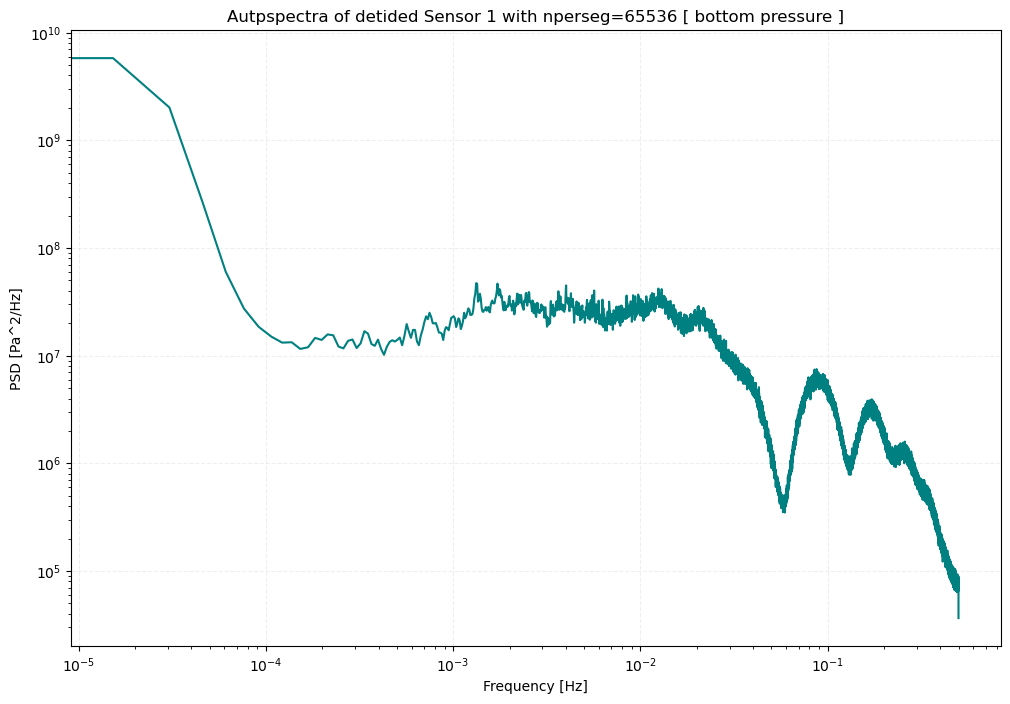

In [15]:
S1pp_mean = np.nanmean(Spp1, axis=1)      # [freq]


plt.figure(figsize=(12, 8))
plt.loglog(freqs1, S1pp_mean, color='teal')
plt.grid(True, linestyle='--', alpha=0.2)
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [Pa^2/Hz]')
plt.title('Autpspectra of detided Sensor 1 with nperseg={} [ bottom pressure ]'.format(nperseg))

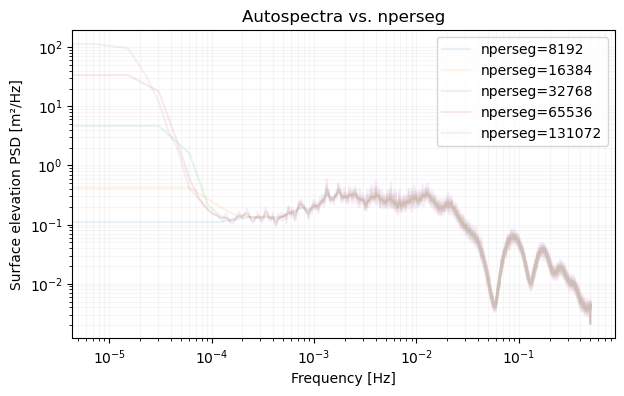

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

fs = 1.0  # Hz
nperseg_list = [8192, 16384, 32768, 65536, 131072]

autospectra = {}
for nperseg in nperseg_list:
    noverlap = int(nperseg * 0.75)
    freqs, t_spec, Spp = spectrogram(
        p1_prime,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        detrend="linear",
        scaling="density",
        mode="psd",
    )
    Seta, *_ = Spp_to_Seta(Spp, freqs, t_spec, t1, h1)
    autospectra[nperseg] = (freqs, np.nanmean(Seta, axis=1))

fig, ax = plt.subplots(figsize=(7, 4))
for nperseg, (freqs, spec) in autospectra.items():
    ax.plot(freqs, spec, label=f"nperseg={nperseg}", alpha=0.1)

ax.set(
    xscale="log",
    yscale="log",
    xlabel="Frequency [Hz]",
    ylabel="Surface elevation PSD [m²/Hz]",
    title="Autospectra vs. nperseg",
)
ax.legend()
ax.grid(True, which="both", alpha=0.1)
plt.show()


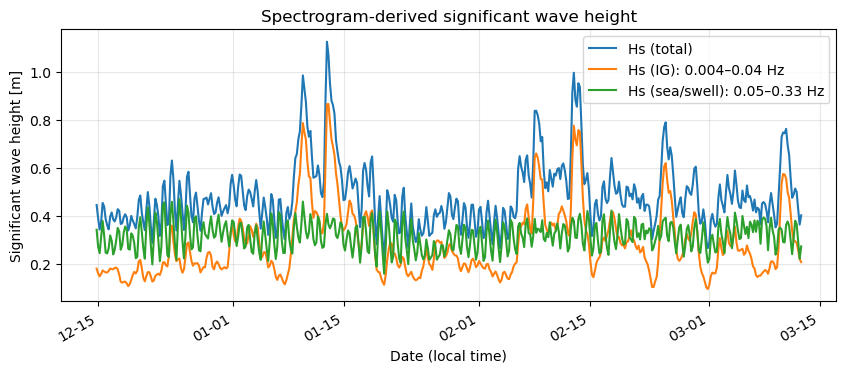

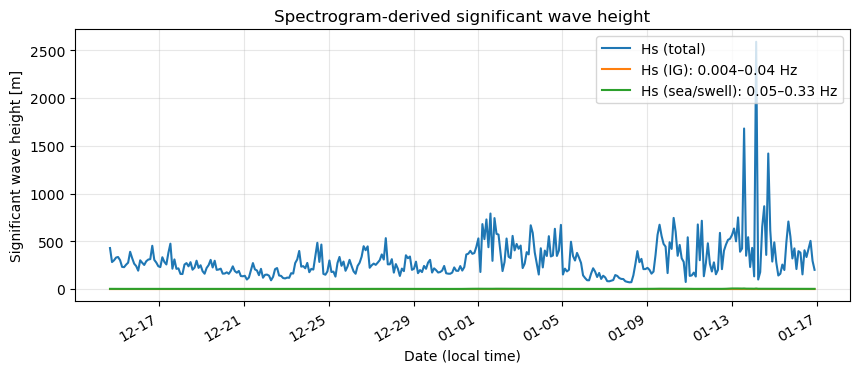

In [31]:
# ----------- Hs Calculations -------- #

# SENSOR 1
hs1_tot, hs1_ig, hs1_ss, tp1_ss, t1_centers = sig_wave_height(S1eta, freqs1, t_spec1, t1, h1)

# SENSOR 6
hs6_tot, hs6_ig, hs6_ss, tp6_ss, t6_centers = sig_wave_height(S6eta, freqs6, t_spec6, t6, h6)

